# XGBoost Classifier
This notebook trains an XGBoost model on the KKBox churn dataset. XGBoost is a gradient boosting algorithm that outperforms Random Forest on tabular data. It handles imbalance via scale_pos_weight.

## 1. Load final dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

#Loading the dataset 
df = pd.read_csv("kkbox_dataset_training.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (970960, 51)
                                           msno  target  transaction_count  \
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=       1                6.0   
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=       1                5.0   
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=       1               18.0   
3  8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=       1               18.0   
4  K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=       1               24.0   

   avg_payment_method  avg_plan_days  total_plan_list_price  \
0           32.166667        30.0000                  298.0   
1           37.000000        25.4000                  627.0   
2           38.000000        30.0000                 2682.0   
3           40.666667        28.5625                 2235.0   
4           41.000000        30.0000                 2529.0   

   total_actual_paid  avg_actual_paid  discount_frequency  renewal_rate  ...  \
0              894.0       149.000000               

# 2. Basic Checks

In [3]:
#Checking number of rows and columns, datatypes, etc. 
print(df.columns.tolist())
print(df["target"].value_counts(dropna=False))
print(df["target"].value_counts(normalize=True, dropna=False))

['msno', 'target', 'transaction_count', 'avg_payment_method', 'avg_plan_days', 'total_plan_list_price', 'total_actual_paid', 'avg_actual_paid', 'discount_frequency', 'renewal_rate', 'cancel_count', 'avg_days_to_expire', 'max_days_to_expire', 'first_transaction_x', 'last_transaction_x', 'last_expire_x', 'total_subscription_length', 'plan_category', 'total_discount', 'max_discount', 'avg_discount_pct', 'discount_bucket', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time_x', 'account_age_days_x', 'Loyalty_Status', 'Age_Group', 'City_Tier', 'total_listening_time', 'avg_daily_usage', 'total_unique_songs', 'total_sessions', 'num_log_days', 'last_log_date_x', 'num_25_sum', 'num_100_sum', 'completion_rate', 'skip_rate', 'first_transaction_y', 'last_transaction_y', 'last_expire_y', 'registration_init_time_y', 'last_log_date_y', 'membership_duration', 'days_since_last_transaction', 'time_until_expiration', 'account_age_days_y', 'days_since_last_log']
target
0    883630
1     8733

## 3. Define features and target

In [4]:
#Defining target variable y and feature set X
#'is_churn' is the label to be predicted
#'msno' is the user identifier

X = df.drop(columns=["target", "msno"], errors="ignore").copy()
y = df["target"].copy()

print("Initial X shape:", X.shape)
print("Initial y shape:", y.shape)

Initial X shape: (970960, 49)
Initial y shape: (970960,)


## 4. Handle missing values

In [5]:
#Check for missing values in the dataset

print("Missing values before fill:", X.isnull().sum().sum())
print(X.isnull().sum().sort_values(ascending=False).head(20))

#Fill numerical missing values with median (robust to outliers) and categorical missing values with 'Unknown'
df.fillna(df.median(numeric_only=True), inplace=True)

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna("Unknown")

print("Missing values after fill:", X.isnull().sum().sum())

Missing values before fill: 5761029
discount_bucket             932476
bd                          584359
Age_Group                   584359
days_since_last_log         218330
last_log_date_y             218330
total_unique_songs          216409
total_sessions              216409
num_log_days                216409
num_100_sum                 216409
completion_rate             216409
total_listening_time        216409
avg_daily_usage             216409
last_log_date_x             216409
num_25_sum                  216409
skip_rate                   216409
account_age_days_y          112025
registration_init_time_y    112025
Loyalty_Status              111900
registered_via              109993
account_age_days_x          109993
dtype: int64
Missing values after fill: 0


## 5. Encode categorical variables

In [6]:
#Convert categorical variables into numerical format 

from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include="object").columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("Shape after encoding:", X.shape)
X.head()

C:\Users\ADMIN 0\AppData\Local\Temp\ipykernel_18472\1051266927.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


Shape after encoding: (970960, 49)


,transaction_count,avg_payment_method,avg_plan_days,total_plan_list_price,total_actual_paid,avg_actual_paid,discount_frequency,renewal_rate,cancel_count,avg_days_to_expire,...,first_transaction_y,last_transaction_y,last_expire_y,registration_init_time_y,last_log_date_y,membership_duration,days_since_last_transaction,time_until_expiration,account_age_days_y,days_since_last_log
0,6.0,32.166667,30.0000,298.0,894.0,149.000000,0.0,0.833333,1.0,25.166667,...,89,618,369,3553,28,730.0,1.0,29.0,1164.0,-28.0
1,5.0,37.000000,25.4000,627.0,627.0,125.400000,0.0,0.000000,0.0,31.000000,...,427,600,351,3553,19,374.0,19.0,11.0,1164.0,-19.0
2,18.0,38.000000,30.0000,2682.0,2682.0,149.000000,0.0,0.000000,0.0,30.611111,...,230,589,346,3557,30,566.0,30.0,6.0,1160.0,-30.0
3,18.0,40.666667,28.5625,2235.0,2533.0,140.722222,0.0,0.944444,2.0,356.944444,...,7,249,347,3570,31,790.0,370.0,7.0,1147.0,-30.0
4,24.0,41.000000,30.0000,2529.0,2956.0,123.166667,0.0,1.000000,2.0,182.708333,...,23,438,344,3586,30,771.0,181.0,4.0,1131.0,-30.0


## 6. Train-test split

In [7]:
#Splitting the data into training and testing sets
#Stratify ensures class distribution is preserved
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (776768, 49)
X_test: (194192, 49)


## 7. Train XGBoost

In [8]:
#scale_pos_weight handles class imbalance
#learning_rate=0.05 with 300 trees gives a careful boosting approach
#max_depth=4 keeps trees shallow to avoid overfitting

from xgboost import XGBClassifier

#Calculate class imbalance ratio for scale_pos_weight
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
print(f"Negative samples: {neg}, Positive samples: {pos}, Ratio: {neg/pos:.2f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)
print("XGBoost model trained successfully.")

Negative samples: 706904, Positive samples: 69864, Ratio: 10.12


c:\Users\ADMIN 0\Downloads\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:08:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained successfully.


## 8. Evaluate model

In [9]:
#Evaluating model performance using classification metrics
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score

#Predict class labels and probabilities on test set
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBOOST RESULTS")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

XGBOOST RESULTS
Accuracy: 0.8812
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93    176726
           1       0.42      0.84      0.56     17466

    accuracy                           0.88    194192
   macro avg       0.70      0.86      0.75    194192
weighted avg       0.93      0.88      0.90    194192

ROC-AUC: 0.9382572780120556
Confusion Matrix: [[156480  20246]
 [  2827  14639]]


# 9. Hypertuning

In [10]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'scale_pos_weight': [1, 2, 5]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=1,
    verbose=1
)

xgb_random.fit(X_train, y_train)

best_xgb = xgb_random.best_estimator_

print("Best Parameters:", xgb_random.best_params_)
print("Best CV ROC-AUC:", xgb_random.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\ADMIN 0\Downloads\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:11:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\ADMIN 0\Downloads\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:11:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\ADMIN 0\Downloads\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:11:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\ADMIN 0\Downloads\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:11:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" }

Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 2, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.9442795801699634


In [11]:

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("TUNED XGBOOST RESULTS")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

TUNED XGBOOST RESULTS
Accuracy: 0.9526

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97    176726
           1       0.77      0.67      0.72     17466

    accuracy                           0.95    194192
   macro avg       0.87      0.82      0.85    194192
weighted avg       0.95      0.95      0.95    194192


ROC-AUC: 0.94433463680591

Confusion Matrix:
[[173314   3412]
 [  5798  11668]]


## 9. Top features


In [12]:
#Extract feature importances from the trained XGBoost model
#Higher importance = feature used more frequently in tree splits

feature_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_features = feature_imp.sort_values(ascending=False)

print("Top 10 Features:")
print(top_features.head(10))

Top 10 Features:
renewal_rate                   0.206793
last_transaction_x             0.143325
last_log_date_y                0.097059
first_transaction_x            0.058999
days_since_last_transaction    0.058968
last_log_date_x                0.055061
cancel_count                   0.039154
membership_duration            0.036709
avg_days_to_expire             0.034356
avg_payment_method             0.020197
dtype: float32


**Confusion Matrix Plot**

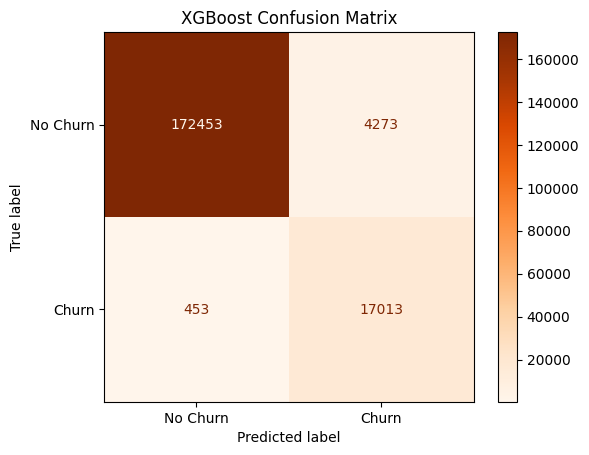

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Oranges")
plt.title("XGBoost Confusion Matrix")
plt.show()

**ROC Curve Plot**

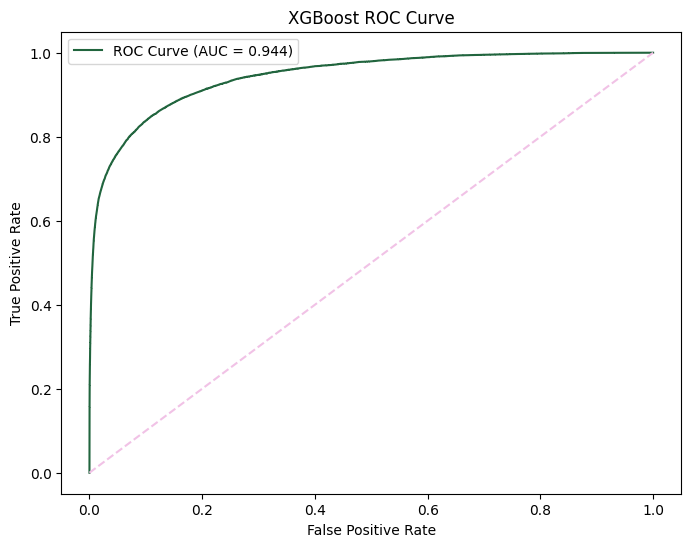

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#21653e", label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="#f1c2e6")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

**Top 15 Feature Importances Plot**

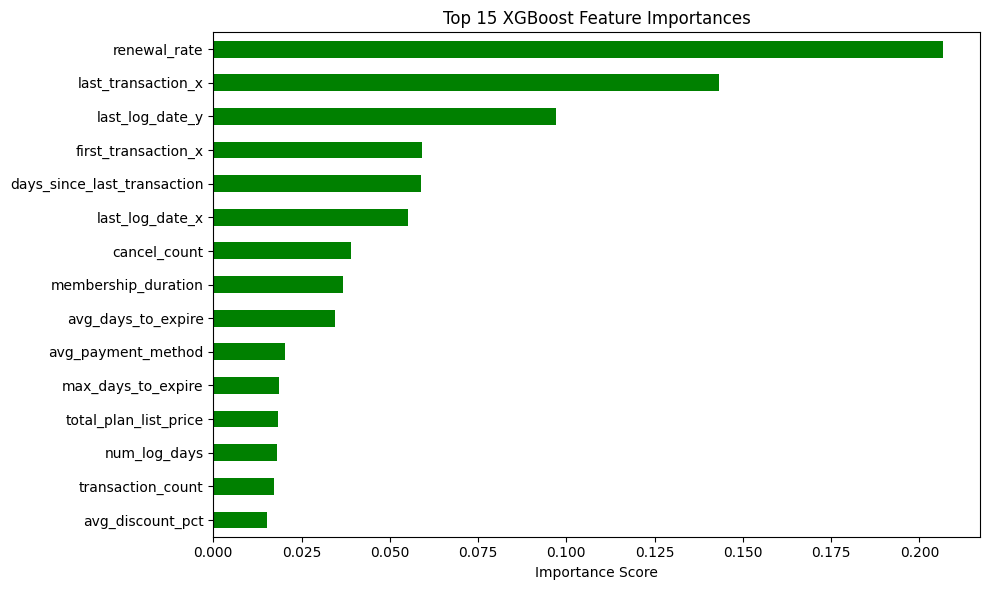

In [14]:
import matplotlib.pyplot as plt

top15 = feature_imp.sort_values(ascending=False).head(15).sort_values()

plt.figure(figsize=(10, 6))
top15.plot(kind="barh", color="green")
plt.xlabel("Importance Score")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

## Insights
The XGBoost model achieved strong predictive performance in identifying churn, demonstrating high accuracy and a strong ROC-AUC score. Its ability to capture nonlinear relationships and interactions between features allowed it to effectively distinguish between churn and non-churn users. The model produced well-balanced predictions, indicating that it generalizes well across the dataset. Overall, XGBoost proved to be a powerful and reliable approach for this classification task.

However, the model still shows some limitations in identifying all churn cases, as reflected by the presence of false negatives. This suggests that while the model performs well overall, there is room for improvement in capturing at-risk users. Hyperparameter tuning helped improve performance and stability while maintaining computational efficiency. Overall, the XGBoost model provides a strong balance between accuracy, robustness, and predictive capability for churn prediction.